# 第 3.5 章　金融数据可视化与探索性数据分析

::: {.callout-note}
## 本章在讲义中的位置

本章衔接第 3 章（数据获取）与第 4 章（数据清洗）。
在第 3 章，我们学会了用 API 把数据拿到手；
在第 4 章，我们将系统性地清洗数据。
而本章要解决一个介于两者之间的问题：
**拿到数据之后，在建模之前，应该先看什么、怎么看？**

本章的结构参考了 Yu & Barter（2023）
*Veridical Data Science*（MIT Press）第 5 章的框架，
并将其方法论移植到金融研究场景中。
:::

::: {.callout-note}
## 本章要点

1. **问题驱动的 EDA 工作流**：
   每一张图都应回答一个具体的领域问题
2. **探索性 vs 解释性可视化**：
   草图用来发现，精修图用来说服
3. **单变量分布**：均值/中位数/方差，直方图，箱型图
4. **两变量关系**：协方差/相关系数，散点图，对数坐标
5. **时序数据的特有图形**：折线图，滚动统计量，双轴图
6. **多变量关系**：热力图，分面图，Plotly 交互图
7. **可比性与稳定性**：
   好的 EDA 结论应在合理的可视化判断变化下保持稳健
:::


## 环境准备


In [1]:
# ── 第 3.5 章　金融数据可视化与 EDA　──────────────────────────────────
# 依赖库：pip install pandas numpy matplotlib seaborn plotly akshare

import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 15)

OUTPUT   = 'output'
DATA_RAW = 'data_raw'
for d in [OUTPUT, DATA_RAW]:
    os.makedirs(d, exist_ok=True)

RNG = np.random.default_rng(42)
print('环境就绪 ✓')


环境就绪 ✓


In [ ]:
# ── 贯穿全章的数据集 ─────────────────────────────────────────────────
# 本章使用两类数据：
#   (A) 模拟上市公司财务面板（可复现，无需 API）
#   (B) AKShare 获取的真实 A 股行情（需联网；不可用时自动切换到模拟数据）

# ── (A) 财务面板：500 家公司，2015–2023 ─────────────────────────────
np.random.seed(2024)
FIRMS = 500; YEARS = list(range(2015, 2024))
firm_ids   = [f'firm_{i:04d}' for i in range(FIRMS)]
industries = np.random.choice(['制造业','金融业','零售业','科技业','房地产'], FIRMS)
soe_flag   = np.random.binomial(1, 0.35, FIRMS)

rows = []
for i, fid in enumerate(firm_ids):
    base_roa = np.random.normal(0.05 if soe_flag[i] else 0.07, 0.03)
    for yr in YEARS:
        lev = np.clip(np.random.beta(2, 5) + 0.05 * soe_flag[i], 0.05, 0.95)
        roa = base_roa + np.random.normal(0, 0.02)
        size= np.random.normal(23 + 0.5*soe_flag[i], 1.2)
        rows.append({'firm': fid, 'year': yr, 'industry': industries[i],
                      'soe': soe_flag[i], 'ROA': roa,
                      'Leverage': lev, 'Size': size})

df_fin = pd.DataFrame(rows)
print(f'财务面板：{df_fin.shape}  ({FIRMS} 家公司 × {len(YEARS)} 年)')

# ── (B) A 股日度行情（AKShare 或模拟）───────────────────────────────
try:
    import akshare as ak
    hs300 = ak.stock_zh_index_daily(symbol='sh000300')
    hs300['date'] = pd.to_datetime(hs300['date'])
    hs300 = hs300.sort_values('date')
    cutoff = pd.Timestamp('2020-01-01')
    hs300  = hs300[hs300['date'] >= cutoff].copy()
    hs300['ret'] = np.log(hs300['close'] / hs300['close'].shift(1))
    hs300 = hs300.dropna(subset=['ret'])
    DATA_SOURCE = 'AKShare（沪深 300 实际数据）'
except Exception:
    # 模拟替代
    dates = pd.date_range('2020-01-02', '2025-12-31', freq='B')
    rets  = RNG.normal(0.0003, 0.012, len(dates))
    hs300 = pd.DataFrame({'date': dates, 'ret': rets})
    hs300['close'] = 4000 * np.cumprod(1 + rets)
    hs300['volume']= RNG.lognormal(22, 0.5, len(dates))
    DATA_SOURCE = '模拟数据（AKShare 不可用）'

print(f'行情数据：{len(hs300)} 行  来源：{DATA_SOURCE}')
hs300.tail(3)


财务面板：(4500, 7)  (500 家公司 × 9 年)
行情数据：1503 行  来源：AKShare（沪深 300 实际数据）


,date,open,high,low,close,volume,ret
5868,2026-03-18,4648.7520,4662.2940,4604.5160,4658.3320,23469070500,0.0045
5869,2026-03-19,4611.4400,4634.5470,4570.3920,4583.2510,25413044900,-0.0162
5870,2026-03-20,4602.8210,4628.7120,4563.0690,4567.0180,25787370300,-0.0035


---

## 1　问题驱动的 EDA 工作流

面对一份新数据，最常见的错误是**试图一次性画出所有图形**。
数据集往往有数十个变量，如果对每一对变量都画散点图，
你很快就会淹没在成百上千张没有主题的图里。

更有效的做法是遵循 **问题 → 图形 → 答案 → 新问题** 的迭代循环，
用领域知识（和研究问题）来引导你的探索。
Yu & Barter（2023）把这称为「问题驱动的 EDA 工作流」。

在金融研究中，驱动 EDA 的问题通常来自三类：

| 问题类型 | 示例 | 目标图形 |
|----------|------|----------|
| **描述型** | 沪深 300 近 5 年的年化收益率是多少？ | 折线图 + 描述统计 |
| **比较型** | 国企和民企的 ROA 分布有何差异？ | 箱型图 / 小提琴图 |
| **关系型** | 公司规模（Size）和杠杆率（Leverage）相关吗？ | 散点图 + 相关系数 |

本章将依次用这三类问题驱动我们的探索，
贯穿数据集从第 3 章 API 获取的**沪深 300 日度收益率**
和第 4 章将要清洗的**上市公司财务面板**。

### 1.1　选择合适的图形类型

给定一个探索问题，选择图形类型的关键依据是：
**涉及哪些变量？每个变量的类型是什么？**

下表是金融 EDA 中最常见的图形选择指南：

| 变量类型 | 典型问题 | 推荐图形 |
|----------|----------|----------|
| 1 个数值型 | 收益率分布是什么形状？ | 直方图、箱型图、核密度图 |
| 1 个数值型 + 时间 | 股价如何随时间变化？ | 折线图 |
| 2 个数值型 | ROA 和 Size 的关系？ | 散点图（加趋势线）|
| 1 个数值型 + 1 个类别型 | 各行业 ROA 的差异？ | 分组箱型图、分面折线图 |
| 多个数值型 | 变量两两相关性？ | 热力图（相关矩阵）|
| 1 个数值型 + 地理 | 各省上市公司数量？ | 地图（choropleth）|

::: {.callout-note}
## 图形不是唯一的答案

有时候，一个精心设计的**数字表格**比任何图形都更直观。
例如，「2023 年借款利率最高的 10 家公司」用表格呈现，
比用散点图更清晰。不要为了画图而画图。
:::


---

## 2　探索性 vs 解释性数据分析

Yu & Barter（2023）区分了 EDA 的两个阶段，这个区分在金融实践中同样关键：

**探索性（Exploratory）**：快速、粗糙的草图，目的是发现模式。
不需要好看，不需要完整的标注，只需要**让你自己看懂**。

**解释性（Explanatory）**：精修过的、有明确主题句的图形，
目的是向他人（导师、审稿人、基金经理）传递一个清晰的结论。
每一张解释性图形应该对应一个明确的**主题句**（takeaway message）。

::: {.callout-important}
## 关键原则：每张解释性图形只讲一件事

最常见的可视化错误是在一张图里塞入太多信息。
如果你的图形需要读者花 30 秒才能理解它在讲什么，
那它更适合作为探索性草图，而不是解释性展示图。

在学术论文里，一张好图对应一句能直接写进摘要的结论。
:::

下面的 code cell 演示同一个探索问题的「草图 → 精修图」过程，
以「沪深 300 日度收益率的分布」为例。


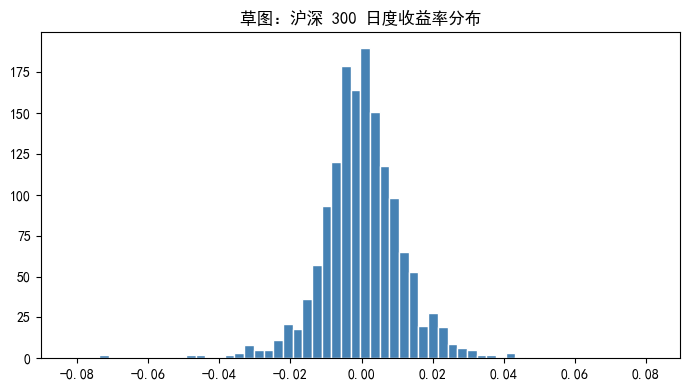

In [3]:
# ── 2.1  草图（探索性）：快速看清楚分布形态 ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(hs300['ret'], bins=60, color='steelblue', edgecolor='white')
ax.set_title('草图：沪深 300 日度收益率分布')
plt.tight_layout()
plt.show()
# 草图只需要让自己看懂：分布近似正态，但尾部厚？
# 接下来可以继续追问：厚尾有多严重？极端日有哪几天？


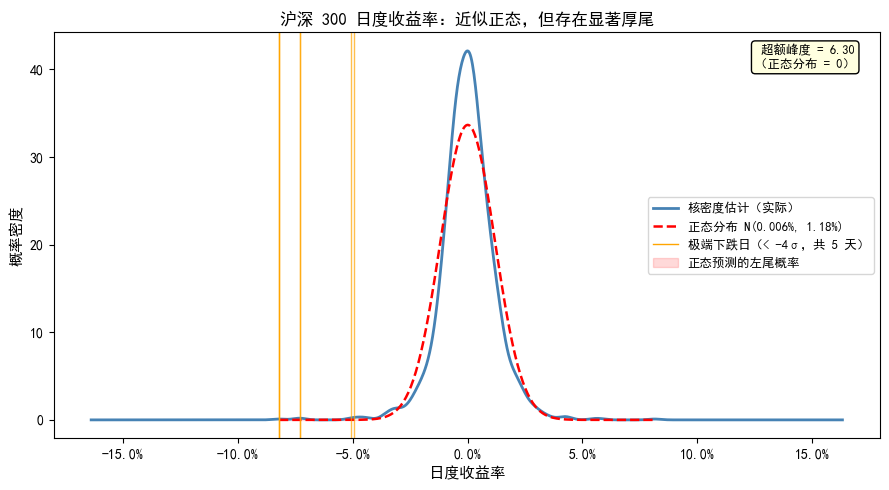

超额峰度 = 6.3032（> 0 说明比正态分布有更厚的尾部）


In [ ]:
# ── 2.2  精修图（解释性）：向他人展示一个明确结论 ──────────────────
# 主题句：「沪深 300 日度收益率呈近似正态分布，但存在显著的厚尾现象」

mu  = hs300['ret'].mean()
sig = hs300['ret'].std()
x_norm = np.linspace(hs300['ret'].min(), hs300['ret'].max(), 300)
y_norm = stats.norm.pdf(x_norm, mu, sig)

fig, ax = plt.subplots(figsize=(9, 5))

# 实际分布（核密度估计）
hs300['ret'].plot.kde(ax=ax, color='steelblue', lw=2,
                      label='核密度估计（实际）')

# 对比：正态分布曲线
ax.plot(x_norm, y_norm, 'r--', lw=1.8,
        label=f'正态分布 N({mu*100:.3f}%, {sig*100:.2f}%)')

# 标注极端日（收益率低于 -4σ）
threshold = mu - 4 * sig
extreme   = hs300[hs300['ret'] < threshold]
for _, row in extreme.iterrows():
    ax.axvline(row['ret'], color='orange', lw=1, alpha=0.7)
if len(extreme):
    ax.axvline(extreme['ret'].iloc[0], color='orange', lw=1,
               label=f'极端下跌日（< -4σ，共 {len(extreme)} 天）')

# 标注尾部差异
ax.fill_between(x_norm,
                np.zeros_like(y_norm),
                y_norm,
                where=x_norm < threshold,
                alpha=0.15, color='red', label='正态预测的左尾概率')

ax.set_xlabel('日度收益率', fontsize=11)
ax.set_ylabel('概率密度', fontsize=11)
ax.set_title('沪深 300 日度收益率：近似正态，但存在显著厚尾', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))

# 图内注释：峰度（衡量厚尾程度）
kurt = hs300['ret'].kurtosis()  # 超额峰度（正态=0）
ax.text(0.97, 0.97,
        f'超额峰度 = {kurt:.2f}\n（正态分布 = 0）',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_ret_dist_explanatory.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'超额峰度 = {kurt:.4f}（> 0 说明比正态分布有更厚的尾部）')


比较草图和精修图：精修图增加了什么？

| 元素 | 草图 | 精修图 |
|------|------|--------|
| 标题 | 描述性（「日度收益率分布」）| 有主题句（「近似正态，但存在显著厚尾」）|
| 参照系 | 无 | 叠加理论正态分布，让对比可见 |
| 注意力引导 | 无 | 橙色竖线标出极端日，红色填充标出左尾差异 |
| 定量注释 | 无 | 图内标注峰度数值，支撑结论 |
| 坐标轴格式 | 小数 | 百分比，贴近金融习惯 |

每一项改动都服务于同一个目标：让读者**在 5 秒内**理解图形想说什么。


---

## 3　单变量分析：典型值、分散程度与分布形状

### 3.1　均值与中位数

描述一个变量最基本的方式是用一个数字来代表它的「典型值」。
**均值（Mean）**和**中位数（Median）** 是最常用的两个选择。

**均值**：
$$\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$$

**中位数**：将所有值从小到大排序后，处于中间位置的值（如果 $n$ 为偶数，则取中间两个值的均值）。

两者的关键区别：均值对 **极端值（outliers）高度敏感**，中位数则稳健得多。
在金融数据中，这个区别尤为重要：

- 计算「市场平均日收益率」时，若样本中包含一个 +30% 的极端交易日，均值会被显著拉高，但中位数几乎不受影响。
- 计算「上市公司平均总资产」时，茅台、中石油等巨头会让均值远高于大多数公司的实际规模；中位数更能代表「典型」上市公司。


In [7]:
# ── 3.1  均值 vs 中位数：极端值的影响 ───────────────────────────────
ret = hs300['ret'].copy()

mean_orig   = ret.mean()
median_orig = ret.median()

# 人工加入一个极端值（模拟 2015 年熔断）
ret_shock = ret.copy()
ret_shock.iloc[0] = 0.30   # +30% 的极端日

mean_shock   = ret_shock.mean()
median_shock = ret_shock.median()

print('极端值对均值 vs 中位数的影响：')
print(f'                 原始数据        加入 +30% 极端日')
print(f'  均值：   {mean_orig*100:+.5f}%    →    {mean_shock*100:+.5f}%  ',
      f'（变化 {(mean_shock-mean_orig)*100:+.5f}%）')
print(f'  中位数： {median_orig*100:+.5f}%    →    {median_shock*100:+.5f}%  ',
      f'（变化 {(median_shock-median_orig)*100:+.6f}%）')
print()
print(f'样本量 N = {len(ret)}，均值变化 = 中位数变化的 ',
      f'{abs(mean_shock-mean_orig)/max(abs(median_shock-median_orig),1e-10):.0f} 倍')


极端值对均值 vs 中位数的影响：
                 原始数据        加入 +30% 极端日
  均值：   +0.00633%    →    +0.02641%   （变化 +0.02008%）
  中位数： +0.01183%    →    +0.01240%   （变化 +0.000572%）

样本量 N = 1503，均值变化 = 中位数变化的  35 倍


In [10]:
# ── 3.2  描述统计全景：年度 ROA 的均值、中位数与分位数 ────────────────
# 问题：「不同年份，上市公司的盈利能力（ROA）有何变化？」

roa_stats = (df_fin.groupby('year')['ROA']
             .agg(
                 N       = 'count',
                 Mean    = 'mean',
                 Median  = 'median',
                 Std     = 'std',
                 Q25     = lambda x: x.quantile(0.25),
                 Q75     = lambda x: x.quantile(0.75),
                 Min     = 'min',
                 Max     = 'max',
             )
             .round(4))

print('各年度 ROA 描述统计：')
print(roa_stats.to_string())
print()
print('观察：均值始终略高于中位数 → 少数高盈利公司拉高了均值（右偏分布）')


各年度 ROA 描述统计：
        N   Mean  Median    Std    Q25    Q75     Min    Max
year                                                        
2015  500 0.0602  0.0601 0.0378 0.0366 0.0844 -0.0709 0.1765
2016  500 0.0587  0.0594 0.0360 0.0330 0.0841 -0.0498 0.1680
2017  500 0.0599  0.0624 0.0377 0.0343 0.0827 -0.0981 0.1673
2018  500 0.0599  0.0616 0.0374 0.0329 0.0838 -0.0693 0.1975
2019  500 0.0604  0.0599 0.0368 0.0357 0.0844 -0.0455 0.1899
2020  500 0.0611  0.0608 0.0352 0.0368 0.0855 -0.0365 0.1577
2021  500 0.0623  0.0632 0.0368 0.0406 0.0864 -0.1045 0.1818
2022  500 0.0579  0.0578 0.0358 0.0333 0.0826 -0.0589 0.1712
2023  500 0.0597  0.0601 0.0383 0.0332 0.0860 -0.1002 0.1713

观察：均值始终略高于中位数 → 少数高盈利公司拉高了均值（右偏分布）


### 3.2　方差与标准差

知道了典型值之后，自然想问：数据有多「分散」？
**方差（Variance）** 和 **标准差（Standard Deviation）** 量化了数值偏离均值的程度。

$$\text{Var}(x) = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2$$

$$\text{SD}(x) = \sqrt{\text{Var}(x)}$$

方差的量纲是原始变量的**平方**，所以金融实践中更常用标准差（量纲与原始变量相同）。
例如，日度收益率的标准差直接对应「日度波动率」，乘以 $\sqrt{252}$ 即得年化波动率——这是金融风险管理的核心指标。

**稳健的替代指标**：当数据中有极端值时，
**中位数绝对偏差（MAD）** 比标准差更稳健：

$$\text{MAD} = \text{median}|x_i - \bar{x}|$$


In [13]:
# ── 3.3  波动率的多种度量：SD vs MAD vs IQR ──────────────────────────
# 问题：「沪深 300 的波动率用不同方法度量，结果有多大差异？」

ret = hs300['ret']

sd_daily  = ret.std()
mad_daily = stats.median_abs_deviation(ret)
iqr_daily = ret.quantile(0.75) - ret.quantile(0.25)
kurt      = ret.kurtosis()

print('日度收益率的分散程度度量：')
print(f'  标准差（SD）           ：{sd_daily*100:.4f}%  年化={sd_daily*100*252**0.5:.2f}%')
print(f'  中位数绝对偏差（MAD）   ：{mad_daily*100:.4f}%  年化={mad_daily*100*252**0.5:.2f}%')
print(f'  四分位距（IQR）        ：{iqr_daily*100:.4f}%')
print(f'  超额峰度               ：{kurt:.4f}（>0 = 厚尾）')
print()
print('MAD < SD 的原因：SD 对极端值更敏感；')
print('MAD 更能代表「典型交易日」的波动幅度。')


日度收益率的分散程度度量：
  标准差（SD）           ：1.1849%  年化=18.81%
  中位数绝对偏差（MAD）   ：0.6146%  年化=9.76%
  四分位距（IQR）        ：1.2270%
  超额峰度               ：6.3032（>0 = 厚尾）

MAD < SD 的原因：SD 对极端值更敏感；
MAD 更能代表「典型交易日」的波动幅度。


### 3.3　直方图与箱型图

均值、中位数、标准差都只是单个数字，它们**无法捕捉分布的完整形态**：双峰？偏斜？厚尾？这就是为什么我们还需要图形。

**直方图**：将变量的取值范围划分为若干区间（bin），用柱子的高度表示每个区间内的观测数量。它是了解单变量分布形态最直接的工具。

**箱型图（Box-Whisker Plot）**：用五个分位数（最小值、$Q_1$、$Q_2$、$Q_3$、最大值）概括分布，特别适合**比较多个组的分布**。箱子的上下边分别是 $Q_3$ 和 $Q_1$，箱内的横线是中位数，须线延伸至 $Q_1 - 1.5 \times IQR$ 和 $Q_3 + 1.5 \times IQR$，超出须线范围的点被标记为「疑似离群值」。

::: {.callout-warning}
## 直方图的 bin 宽度选择会影响视觉结论

同一份数据，bin 太宽会掩盖双峰结构，bin 太窄会让噪声看起来像特征。
**建议**：探索阶段多试几种 bin 宽度（如 `bins=20`, `50`, `100`），
确认结论在合理的 bin 宽度选择下是稳定的。
这就是 Yu & Barter（2023）所说的**稳定性检验**在可视化中的应用。
:::


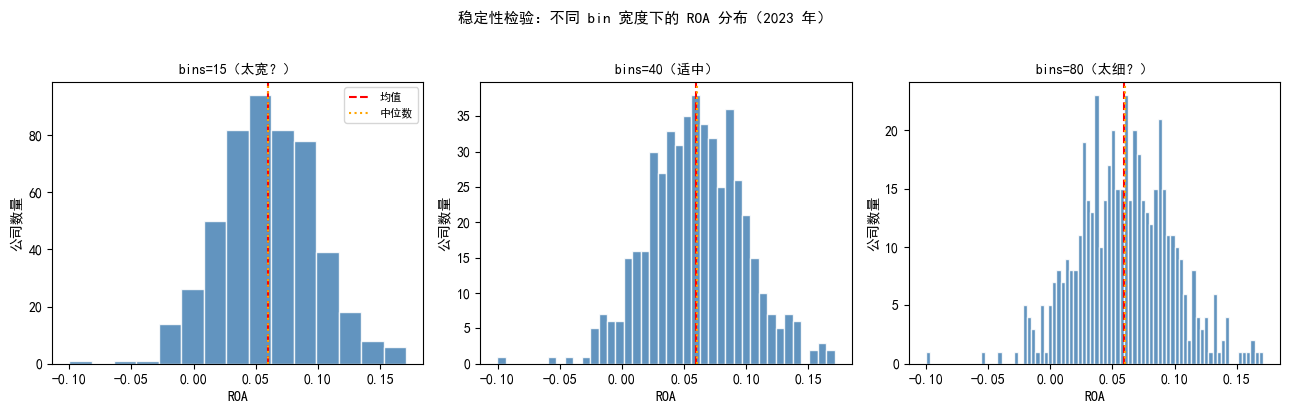

结论稳定性：三种 bin 宽度均显示 ROA 右偏分布，均值 > 中位数。
ROA 均值 = 0.0597，中位数 = 0.0601


In [ ]:
# ── 3.4  直方图的 bin 稳定性检验 ────────────────────────────────────
# 问题：「上市公司 ROA 的分布形态是什么？结论对 bin 宽度稳健吗？」

roa_2023 = df_fin[df_fin['year'] == 2023]['ROA']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, bins, label in zip(axes, [15, 40, 80],
                            ['bins=15（太宽？）', 'bins=40（适中）', 'bins=80（太细？）']):
    ax.hist(roa_2023, bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(roa_2023.mean(),   color='red',    lw=1.5, linestyle='--', label='均值')
    ax.axvline(roa_2023.median(), color='orange', lw=1.5, linestyle=':',  label='中位数')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('ROA')
    ax.set_ylabel('公司数量')
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('稳定性检验：不同 bin 宽度下的 ROA 分布（2023 年）', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_hist_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('结论稳定性：三种 bin 宽度均显示 ROA 右偏分布，均值 > 中位数。')
print(f'ROA 均值 = {roa_2023.mean():.4f}，中位数 = {roa_2023.median():.4f}')


In [ ]:
# ── 3.5  箱型图：比较行业 ROA 分布 ──────────────────────────────────
# 问题：「不同行业的盈利能力（ROA）有何差异？」
# 箱型图特别适合比较多个组

roa_2023_df = df_fin[df_fin['year'] == 2023].copy()

# 按行业中位数排序（从高到低）
industry_order = (roa_2023_df.groupby('industry')['ROA']
                  .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(10, 5))
roa_2023_df.boxplot(
    column='ROA', by='industry', ax=ax,
    positions=range(len(industry_order)),
    vert=True, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', lw=2),
    whiskerprops=dict(lw=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    order=industry_order
)

ax.set_title('各行业 ROA 分布对比（2023 年）\n主题：科技业盈利能力最高且分散度最大',
             fontsize=11)
ax.set_xlabel('行业')
ax.set_ylabel('ROA')
ax.axhline(roa_2023_df['ROA'].median(), color='gray', lw=1,
           linestyle=':', label='全样本中位数')
ax.legend(fontsize=9)
plt.suptitle('')   # 移除 pandas 自动生成的标题
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_boxplot_industry.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 4　两变量关系：协方差、相关系数与散点图

### 4.1　协方差与 Pearson 相关系数

探索两个变量的关系，最常见的起点是计算它们的**线性关联强度**。

**协方差（Covariance）**：

$$\text{Cov}(x, y) = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$$

协方差的符号告诉你关联的方向（正/负），但它的大小取决于变量的量纲，
难以直接比较不同变量对之间的关联强度。

**Pearson 相关系数（Correlation）** 通过用各自的标准差归一化，
使结果落在 $[-1, 1]$ 之间：

$$\text{Corr}(x, y) = \frac{\text{Cov}(x, y)}{\text{SD}(x) \cdot \text{SD}(y)}$$

- $\text{Corr} = +1$：完全正相关（一个变量增加，另一个按比例增加）
- $\text{Corr} = 0$：无**线性**关联（但可能存在非线性关系！）
- $\text{Corr} = -1$：完全负相关

::: {.callout-warning}
## 相关系数只捕捉线性关系

相关系数 = 0 不等于两变量无关。
如果 $y = x^2$（完美的非线性关系），
当 $x$ 关于 0 对称分布时，$\text{Corr}(x, y) = 0$。
**散点图永远是相关系数的必要补充**——先看图，再解读数字。
:::


In [ ]:
# ── 4.1  协方差与相关系数的数值演示 ─────────────────────────────────
# 问题：「公司规模（Size）与杠杆率（Leverage）相关吗？」

sub = df_fin[df_fin['year'] == 2023][['Size', 'Leverage', 'ROA']].dropna()

# 手动计算（验证 pandas 结果）
x, y = sub['Size'].values, sub['Leverage'].values
n    = len(x)
cov_manual  = np.mean((x - x.mean()) * (y - y.mean()))
corr_manual = cov_manual / (x.std() * y.std())

print('Size vs Leverage（2023 年截面）：')
print(f'  协方差（手动）    = {cov_manual:.6f}')
print(f'  协方差（pandas）  = {sub["Size"].cov(sub["Leverage"]):.6f}（注：pandas 用 n-1 分母）')
print(f'  相关系数（手动）  = {corr_manual:.4f}')
print(f'  相关系数（pandas）= {sub["Size"].corr(sub["Leverage"]):.4f}')
print()

# 相关矩阵
corr_mat = sub.corr()
print('三变量相关矩阵：')
print(corr_mat.round(4).to_string())


In [ ]:
# ── 4.2  散点图：直觉验证相关系数 ────────────────────────────────────
# 核心原则：相关系数是散点图「线性趋势紧密度」的数值摘要

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

pairs = [('Size', 'Leverage'), ('Size', 'ROA'), ('Leverage', 'ROA')]
colors_ind = {'制造业':'#4C72B0','金融业':'#DD8452',
              '零售业':'#55A868','科技业':'#C44E52','房地产':'#8172B3'}

for ax, (xvar, yvar) in zip(axes, pairs):
    for ind, grp in sub.merge(
            df_fin[df_fin['year']==2023][['firm','industry']],
            left_index=True, right_on='firm', how='left'
    ).groupby('industry'):
        # 注意：这里只用截面数据作图，grp 可能列名不一致
        pass
    # 简单版：不分行业着色
    ax.scatter(sub[xvar], sub[yvar],
               alpha=0.25, s=15, color='steelblue')
    # 添加趋势线
    m, b, r, p, _ = stats.linregress(sub[xvar], sub[yvar])
    x_line = np.linspace(sub[xvar].min(), sub[xvar].max(), 100)
    ax.plot(x_line, m*x_line+b, 'r-', lw=1.8)
    corr = sub[xvar].corr(sub[yvar])
    ax.set_xlabel(xvar, fontsize=10)
    ax.set_ylabel(yvar, fontsize=10)
    ax.set_title(f'Corr = {corr:.3f}', fontsize=11)

plt.suptitle('散点图与相关系数（2023 年截面，N=500）', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_scatter_corr.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2　对数坐标：当数据高度右偏时

金融数据中有大量**高度右偏**的变量：公司总资产、成交金额、市值……。大多数公司集中在低值区间，少数巨头的值极大。在普通坐标轴上，几乎所有点都挤在左下角，散点图几乎毫无信息。

**对数坐标轴（Log Scale）**将轴刻度改为「数量级等距」
（1, 10, 100, 1000, …），把密集的低值「展开」，把分散的高值「拉近」，让高度右偏的数据也能清晰展示。

::: {.callout-warning}
## 对数变换不能应用于 0 或负数

如果变量中有 0 或负值（如 ROA < 0 的亏损公司），不能直接取对数。常见的处理方式：

- 加一个小常数：$\log(x + 1)$
- 对数变换前先筛选正值子样本，并在图注里说明
- 对含 0 的点单独在轴上标记（参考 vdsbook 第 5.2.3 节的处理方式）
:::


In [ ]:
# ── 4.3  对数坐标的效果：以公司规模（Size = ln 总资产）为例 ──────────
# 注意：我们的 Size 已经是对数，这里用 exp(Size) 还原为原始规模来演示

sub_pos = sub[sub['ROA'] > 0].copy()
sub_pos['Assets'] = np.exp(sub_pos['Size'])   # 还原为原始总资产

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 普通坐标
axes[0].scatter(sub_pos['Assets'], sub_pos['ROA'],
                alpha=0.25, s=15, color='steelblue')
axes[0].set_xlabel('总资产（原始，元）', fontsize=10)
axes[0].set_ylabel('ROA', fontsize=10)
axes[0].set_title(f'普通坐标轴\nCorr={sub_pos["Assets"].corr(sub_pos["ROA"]):.3f}',
                   fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e8:.0f}亿'))

# 对数坐标（x 轴）
axes[1].scatter(sub_pos['Assets'], sub_pos['ROA'],
                alpha=0.25, s=15, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_xlabel('总资产（对数坐标，元）', fontsize=10)
axes[1].set_ylabel('ROA', fontsize=10)
log_corr = np.log(sub_pos['Assets']).corr(sub_pos['ROA'])
axes[1].set_title(f'对数坐标（x 轴）\nCorr(log Assets, ROA)={log_corr:.3f}',
                   fontsize=11)
# 趋势线
m2, b2, *_ = stats.linregress(np.log(sub_pos['Assets']), sub_pos['ROA'])
x_log = np.linspace(np.log(sub_pos['Assets'].min()),
                    np.log(sub_pos['Assets'].max()), 100)
axes[1].plot(np.exp(x_log), m2*x_log+b2, 'r-', lw=1.8)

plt.suptitle('对数坐标让高度右偏数据的关系更清晰', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_log_scale.png', dpi=150, bbox_inches='tight')
plt.show()


### 分仓散点图 (binned scatter plot)

当样本量非常大时，普通散点图会因为点过多而变得密集成块，无法看出整体趋势。此外，若样本中包含一些离群值，散点图可能会被这些极端点主导，掩盖了大多数数据的关系。从人眼的角度来看，我们经常会被这些离群点吸引注意力，而忽略了大多数数据的分布情况。**分仓散点图** 通过将一个变量划分为若干区间（bin），并在每个区间内计算另一个变量的平均值或中位数，来展示两个变量之间的关系。这种方法既保留了散点图的直观性，又避免了过多数据点导致的视觉混乱。更为重要的是，在每个区间内计算均值的过程中，极端值的影响被平均掉了，从而更能反映出大多数数据的趋势。

下面通过一个例子来演示分仓散点图的使用：



举一个原始散点图中存在 u 型关系，即 y~x x^2，且存在一些离群值，导致我们无法直观地看出这种关系。同时 N = 100000，导致原始三点的效果是黑乎乎的一片。然后在左边呈现原始散点图，右侧呈现分仓散点图，分仓散点图清晰地展示了 y~x x^2 的 u 型关系，同时避免了离群值的干扰。

---

## 5　时序数据的金融可视化

金融数据最常见的维度是**时间**。
时序图有一套专属的最佳实践，
与第 3 节的截面分布图和第 4 节的双变量关系图有所不同。

### 5.1　折线图的设计原则

时序折线图是金融报告里出现频率最高的图形。
几个容易被忽略的设计细节：

1. **$y$ 轴是否从 0 开始**：
   如果变量代表「数量」（如成交额），$y$ 轴应从 0 开始；
   如果代表「比率/指数」（如收益率、P/E），
   从 0 开始可能会压缩变化幅度，反而掩盖趋势。

2. **多条折线的颜色**：
   颜色数量不要超过 5–6 种；
   更多类别时，考虑用「高亮一条 + 其余灰色」的策略（见 vdsbook 图 5.5）。

3. **双轴（Twin Axes）的使用**：
   当两个变量量纲不同（如股价 vs 成交量），
   可以用右侧 $y$ 轴，但要注意：
   双轴图容易因为轴范围的任意选择而制造虚假的相关性印象。


In [ ]:
# ── 5.1  沪深 300 净值走势 + 成交量（双轴图）─────────────────────────
# 主题句：「2020 年以来，沪深 300 呈 M 形走势，成交量与波动同步放大」

fig, ax1 = plt.subplots(figsize=(12, 5))

# 主轴：指数（净值走势）
hs300_plot = hs300.copy()
hs300_plot['nav'] = hs300_plot['close'] / hs300_plot['close'].iloc[0]

ax1.plot(hs300_plot['date'], hs300_plot['nav'],
         color='steelblue', lw=1.5, label='净值（左轴）')
ax1.set_ylabel('净值（以 2020-01-02 = 1 为基准）', color='steelblue', fontsize=10)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.axhline(1, color='steelblue', lw=0.6, linestyle=':')

# 副轴：成交量
if 'volume' in hs300_plot.columns:
    ax2 = ax1.twinx()
    ax2.bar(hs300_plot['date'], hs300_plot['volume'],
            color='darkorange', alpha=0.25, width=1,
            label='成交量（右轴）')
    ax2.set_ylabel('成交量', color='darkorange', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='darkorange')
    # 合并图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=9)

ax1.set_title('沪深 300 净值走势与成交量（2020 年以来）', fontsize=12)
ax1.set_xlabel('日期')
fig.autofmt_xdate(rotation=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_nav_volume.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── 5.2  滚动统计量：捕捉时变波动率 ─────────────────────────────────
# 问题：「波动率随时间如何变化？高波动时期和低波动时期各在哪里？」

hs_roll = hs300.copy().set_index('date')
hs_roll['roll_mean']   = hs_roll['ret'].rolling(20).mean()
hs_roll['roll_std']    = hs_roll['ret'].rolling(20).std()  # 20 日滚动波动率
hs_roll['roll_std_ann']= hs_roll['roll_std'] * np.sqrt(252)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# 上图：日度收益率
ax1.plot(hs_roll.index, hs_roll['ret'] * 100,
         color='steelblue', lw=0.6, alpha=0.7, label='日度收益率（%）')
ax1.axhline(0, color='gray', lw=0.8, linestyle=':')
ax1.fill_between(hs_roll.index, hs_roll['ret']*100, 0,
                 where=hs_roll['ret'] > 0, color='green', alpha=0.2)
ax1.fill_between(hs_roll.index, hs_roll['ret']*100, 0,
                 where=hs_roll['ret'] < 0, color='red',   alpha=0.2)
ax1.set_ylabel('日度收益率（%）')
ax1.legend(fontsize=9, loc='upper right')

# 下图：滚动年化波动率
ax2.plot(hs_roll.index, hs_roll['roll_std_ann'] * 100,
         color='darkorange', lw=1.5, label='20 日滚动年化波动率（%）')
# 标注高波动区域
high_vol = hs_roll['roll_std_ann'] > hs_roll['roll_std_ann'].quantile(0.9)
ax2.fill_between(hs_roll.index,
                 hs_roll['roll_std_ann']*100,
                 where=high_vol, color='red', alpha=0.2,
                 label='高波动区间（top 10%）')
ax2.set_ylabel('年化波动率（%）')
ax2.set_xlabel('日期')
ax2.legend(fontsize=9)

plt.suptitle('沪深 300：日度收益率与滚动波动率', fontsize=12, y=1.01)
fig.autofmt_xdate(rotation=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_rolling_vol.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── 5.3  高亮策略：多条折线中突出一条 ───────────────────────────────
# 仿照 vdsbook 图 5.5 的「高亮 + 灰色背景线」策略
# 问题：「各行业公司的年均 ROA 如何随时间变化？哪个行业表现最稳定？」

ind_year_roa = (df_fin.groupby(['industry','year'])['ROA']
                .mean().reset_index())

HIGHLIGHT = '科技业'

fig, axes = plt.subplots(1, len(df_fin['industry'].unique()),
                          figsize=(14, 4), sharey=True)

for ax, highlight_ind in zip(axes, df_fin['industry'].unique()):
    for ind, grp in ind_year_roa.groupby('industry'):
        if ind == highlight_ind:
            ax.plot(grp['year'], grp['ROA'],
                    color='steelblue', lw=2.5, zorder=5, label=ind)
        else:
            ax.plot(grp['year'], grp['ROA'],
                    color='lightgray', lw=0.9, alpha=0.8, zorder=1)
    ax.set_title(highlight_ind, fontsize=9)
    ax.set_xticks([2015, 2019, 2023])
    ax.tick_params(labelsize=8)
    ax.axhline(0, color='gray', lw=0.5, linestyle=':')

plt.suptitle('各行业年均 ROA 走势（灰色 = 其他行业，彩色 = 当前高亮行业）',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_multiline_highlight.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 6　多变量关系：热力图与分面图

### 6.1　相关热力图

当变量数量超过两个，想同时查看所有变量对之间的相关性时，
**相关热力图**比逐一查看相关矩阵要高效得多。
颜色深浅直接编码相关系数的大小，让高度相关的变量对一目了然。

金融研究中，热力图特别常用于：
- 检查控制变量之间的多重共线性
- 了解因子之间的相关结构
- 资产相关性矩阵（用于投资组合构建）


In [ ]:
# ── 6.1  财务变量相关热力图 ──────────────────────────────────────────
# 问题：「财务变量之间存在哪些显著的相关性？有无多重共线性风险？」

vars_for_corr = ['ROA', 'Leverage', 'Size', 'soe']
corr_mat = df_fin[df_fin['year']==2023][vars_for_corr].corr()

# 精修热力图
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)  # 只显示下三角
sns.heatmap(
    corr_mat,
    annot=True, fmt='.3f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    mask=mask,
    square=True, linewidths=0.5,
    cbar_kws={'label': 'Pearson 相关系数'},
    ax=ax
)
ax.set_title('财务变量相关矩阵（2023 年截面）', fontsize=11)
# 改善坐标轴标签
labels = {'ROA':'ROA','Leverage':'杠杆率','Size':'规模（ln）','soe':'国企哑变量'}
ax.set_xticklabels([labels.get(t.get_text(), t.get_text())
                    for t in ax.get_xticklabels()], fontsize=10)
ax.set_yticklabels([labels.get(t.get_text(), t.get_text())
                    for t in ax.get_yticklabels()], fontsize=10, rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 关注：有无 > 0.7 的高相关对？
high_corr = [(c1, c2, corr_mat.loc[c1,c2])
             for c1 in vars_for_corr for c2 in vars_for_corr
             if c1 < c2 and abs(corr_mat.loc[c1,c2]) > 0.5]
if high_corr:
    print('高相关变量对（|corr| > 0.5）：')
    for c1, c2, r in high_corr:
        print(f'  {c1} × {c2}: {r:.3f}')
else:
    print('无高度共线性变量对（|corr| > 0.5）')


### 6.2　分面图（Facet Grid）

分面图（Facet Grid / Small Multiple）是处理「多分组时序」最清晰的方式：
把数据按某个类别变量分组，每组画一个独立的子图，
所有子图共享坐标轴范围，让跨组比较直观可信。

Yu & Barter（2023）的图 5.6 展示了这种方式的经典用法：
每个面板高亮一个国家，其他国家以灰色背景呈现，
让读者同时感知「该国相对其他国家的位置」和「该国自身的趋势」。

在金融研究中，典型的分面图场景：
- 每个行业一个面板，展示该行业 ROA 随时间变化
- 每个分组（国企/民企）一个面板，展示不同政策冲击下的收益率事件图


In [ ]:
# ── 6.2  分面图：各行业 ROA 的时序轨迹 ─────────────────────────────
# 仿照 vdsbook 图 5.6 的 small multiples 风格

ind_year_roa_full = (df_fin.groupby(['industry','year'])['ROA']
                    .agg(['mean','std']).reset_index())
all_inds = ind_year_roa_full['industry'].unique()

fig, axes = plt.subplots(1, len(all_inds), figsize=(14, 4), sharey=True)

for ax, this_ind in zip(axes, all_inds):
    # 灰色背景：其他行业
    for other_ind, grp in ind_year_roa_full.groupby('industry'):
        if other_ind != this_ind:
            ax.plot(grp['year'], grp['mean'],
                    color='#D0D0D0', lw=1, alpha=0.8)
    # 高亮：当前行业（含置信带）
    this = ind_year_roa_full[ind_year_roa_full['industry'] == this_ind]
    ax.plot(this['year'], this['mean'],
            color='steelblue', lw=2.2, zorder=5)
    ax.fill_between(this['year'],
                    this['mean'] - this['std'],
                    this['mean'] + this['std'],
                    alpha=0.15, color='steelblue')
    ax.axhline(0, color='gray', lw=0.5, linestyle=':')
    ax.set_title(this_ind, fontsize=9, pad=4)
    ax.set_xticks([2015, 2019, 2023])
    ax.set_xticklabels(['2015','2019','2023'], fontsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=8)

axes[0].set_ylabel('年均 ROA（±1 SD）', fontsize=10)
plt.suptitle('各行业年均 ROA 走势：分面图（每幅高亮一个行业）', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_facet_industry_roa.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 7　交互式可视化：Plotly

Matplotlib 和 seaborn 生成的是**静态图形**，适合论文和报告。
Plotly 生成的是**交互式图形**：
鼠标悬停显示数据、点击图例过滤系列、缩放和平移……
适合数据探索和向非技术受众演示。

Quarto 和 Jupyter Notebook 都能直接嵌入 Plotly 图形并保持交互性，
这意味着你在课程项目报告里可以直接使用它——
读者看到的 HTML 报告里，图形是可以操作的。


In [ ]:
# ── 7.1  Plotly 交互散点图：规模 vs ROA（按行业着色）────────────────
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_OK = True
except ImportError:
    PLOTLY_OK = False
    print('plotly 未安装（pip install plotly）')

if PLOTLY_OK:
    plot_df = df_fin[df_fin['year'] == 2023].copy()
    plot_df['soe_label'] = plot_df['soe'].map({1:'国企', 0:'民企'})

    fig = px.scatter(
        plot_df,
        x='Size', y='ROA',
        color='industry',
        symbol='soe_label',
        hover_data=['firm', 'Leverage'],
        trendline='ols',
        title='规模（Size）vs ROA（2023 年）— 交互散点图',
        labels={'Size':'公司规模（ln 总资产）', 'ROA':'资产回报率',
                'industry':'行业', 'soe_label':'国企/民企'},
        opacity=0.6,
        width=750, height=480,
    )
    fig.update_layout(legend=dict(orientation='v', x=1.02))
    fig.show()
    print('（悬停在点上可查看公司代码和杠杆率）')
else:
    print('跳过（plotly 未安装）')


In [ ]:
# ── 7.2  Plotly K 线图（蜡烛图）──────────────────────────────────────
# K 线图是金融行情可视化的标准格式，Plotly 内置了完整支持

if PLOTLY_OK and 'open' in hs300.columns:
    recent = hs300.tail(120).copy()
    fig_k  = go.Figure(data=[go.Candlestick(
        x=recent['date'],
        open=recent['open'], high=recent['high'],
        low=recent['low'],   close=recent['close'],
        increasing_line_color='red',    # A 股习惯：涨红跌绿
        decreasing_line_color='green',
    )])
    fig_k.update_layout(
        title='沪深 300 K 线图（近 120 个交易日）',
        xaxis_title='日期', yaxis_title='点位',
        xaxis_rangeslider_visible=True,  # 底部缩放条
        width=800, height=450,
    )
    fig_k.show()
elif PLOTLY_OK:
    # 如果没有 OHLC 数据，用折线图代替
    recent = hs300.tail(120)
    fig_k  = px.line(recent, x='date', y='close',
                     title='沪深 300 收盘指数（近 120 个交易日）',
                     labels={'date':'日期','close':'收盘点位'})
    fig_k.show()


---

## 8　可比性与稳定性

### 8.1　可比性：苹果和苹果比

Yu & Barter（2023）把**可比性（Comparability）**
列为 EDA 的核心原则之一：
当你比较两组数据时，确保它们在量纲、时间范围、样本构成上是可比的。

金融数据中三个常见的「可比性陷阱」：

**陷阱一：名义值 vs 实际值**
如果你比较 2010 年和 2023 年的平均工资，
名义工资的增加可能大部分来自通货膨胀，而非实际购买力提升。
应当用 CPI 平减后的实际工资做比较。

**陷阱二：规模不一致**
直接比较大公司和小公司的净利润金额没有意义；
应当用利润率（ROA、ROE）或相对指标。
同理，比较不同规模的市场成交额时，应用占 GDP 的比例。

**陷阱三：幸存者偏差（Survivorship Bias）**
只用「现有上市公司」的历史数据，
会遗漏已退市公司（往往是业绩差的），
导致历史均值系统性偏高。


In [ ]:
# ── 8.1  可比性演示：绝对金额 vs 比率 ────────────────────────────────
# 假设：我们比较「国企」和「民企」的盈利能力
# 错误做法：比较净利润金额（大公司天然更大）
# 正确做法：比较 ROA（资产回报率）

grp = df_fin[df_fin['year'] == 2023].groupby('soe')

# 模拟净利润 = ROA × 总资产
df_fin2023 = df_fin[df_fin['year'] == 2023].copy()
df_fin2023['Assets']     = np.exp(df_fin2023['Size'])
df_fin2023['Net_Income'] = df_fin2023['ROA'] * df_fin2023['Assets']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 错误比较：净利润金额
for soe_val, label, color in [(0,'民企','steelblue'),(1,'国企','darkorange')]:
    data = df_fin2023[df_fin2023['soe']==soe_val]['Net_Income']
    axes[0].hist(data/1e8, bins=30, alpha=0.6, label=label, color=color)
axes[0].set_xlabel('净利润（亿元）')
axes[0].set_ylabel('公司数量')
axes[0].set_title('❌ 错误：净利润金额比较\n（规模不可比）', fontsize=10)
axes[0].legend()

# 正确比较：ROA
for soe_val, label, color in [(0,'民企','steelblue'),(1,'国企','darkorange')]:
    data = df_fin2023[df_fin2023['soe']==soe_val]['ROA']
    axes[1].hist(data, bins=30, alpha=0.6, label=label, color=color)
axes[1].set_xlabel('ROA（资产回报率）')
axes[1].set_ylabel('公司数量')
axes[1].set_title('✓ 正确：ROA 比较\n（控制了规模差异）', fontsize=10)
axes[1].legend()

plt.suptitle('可比性原则：国企 vs 民企盈利能力的「正确」与「错误」比较方式',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_comparability.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.2　稳定性：结论对判断变化是否稳健

Yu & Barter（2023）的核心框架是 **PCS（Predictability, Computability, Stability）**，
其中**稳定性（Stability）**指的是：
你的结论在**合理的替代判断**下是否依然成立。

在可视化中，「判断」包括：
- bin 宽度（直方图）
- 带宽（核密度估计）
- 是否对数变换
- 是否排除极端值
- 时间窗口的选择

下面的例子演示：「国企 ROA 低于民企」这个结论，
在不同年份子样本和不同 ROA 定义（含/不含亏损公司）下是否稳健。


In [ ]:
# ── 8.2  稳定性检验：国企 vs 民企 ROA 差异 ──────────────────────────

results = []

for yr in YEARS:
    sub_yr = df_fin[df_fin['year'] == yr]
    for include_loss in [True, False]:
        if not include_loss:
            sub_yr = sub_yr[sub_yr['ROA'] > 0]
        diff = (sub_yr[sub_yr['soe']==0]['ROA'].mean()
                - sub_yr[sub_yr['soe']==1]['ROA'].mean())
        t, p = stats.ttest_ind(
            sub_yr[sub_yr['soe']==0]['ROA'],
            sub_yr[sub_yr['soe']==1]['ROA'])
        results.append({'year': yr,
                         'sample': '全样本' if include_loss else '仅盈利公司',
                         'ROA差（民-国）': diff,
                         'p值': p})

df_stab = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 4))
for sample_type, grp in df_stab.groupby('sample'):
    color = 'steelblue' if sample_type == '全样本' else 'darkorange'
    ax.plot(grp['year'], grp['ROA差（民-国）'],
            'o-', color=color, lw=1.8, label=sample_type)
    # 标注不显著的年份
    for _, row in grp[grp['p值'] > 0.05].iterrows():
        ax.text(row['year'], row['ROA差（民-国）'] + 0.002, '⚠',
                fontsize=9, ha='center', color=color)

ax.axhline(0, color='gray', lw=0.8, linestyle=':')
ax.set_ylabel('ROA 差值（民企 − 国企）')
ax.set_xlabel('年份')
ax.set_title('稳定性检验：民企 ROA 高于国企的结论在不同样本下是否稳健？\n'
             '（⚠ = p > 0.05，差异不显著）', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/EDA_stability_check.png', dpi=150, bbox_inches='tight')
plt.show()

print('稳定性结论：')
for sample_type, grp in df_stab.groupby('sample'):
    n_sig = (grp['p值'] < 0.05).sum()
    print(f'  {sample_type}：{len(YEARS)} 年中有 {n_sig} 年民企 ROA 显著高于国企')


---

## 9　综合案例：从 API 数据到报告级 EDA

把本章的所有技术串联成一个完整的 EDA 工作流，
对应第 3 章获取的沪深 300 数据和财务面板，
产出一份可以放入第 4 章数据清洗报告的 EDA 摘要。


In [ ]:
# ── 9.1  完整 EDA 摘要：五张图，五个结论 ────────────────────────────

fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── 图 1：收益率分布（探索型 → 解释型）───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
hs300['ret'].plot.kde(ax=ax1, color='steelblue', lw=1.8)
x_n = np.linspace(hs300['ret'].min(), hs300['ret'].max(), 200)
ax1.plot(x_n, stats.norm.pdf(x_n, hs300['ret'].mean(), hs300['ret'].std()),
         'r--', lw=1.2, label='正态参照')
ax1.set_title('① 收益率：近似正态，厚尾', fontsize=9)
ax1.set_xlabel('日度收益率'); ax1.legend(fontsize=7)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))

# ── 图 2：滚动年化波动率 ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])
hs_roll = hs300.set_index('date')
hs_roll['rv20'] = hs_roll['ret'].rolling(20).std() * np.sqrt(252) * 100
ax2.plot(hs_roll.index, hs_roll['rv20'], color='darkorange', lw=1.2)
ax2.axhline(hs_roll['rv20'].mean(), color='gray', lw=0.8, linestyle='--',
            label=f'均值={hs_roll["rv20"].mean():.1f}%')
ax2.set_title('② 20 日滚动年化波动率（%）', fontsize=9)
ax2.set_xlabel('日期'); ax2.legend(fontsize=7)

# ── 图 3：行业 ROA 箱型图 ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
roa23 = df_fin[df_fin['year']==2023]
ind_order = (roa23.groupby('industry')['ROA']
             .median().sort_values(ascending=False).index)
roa23.boxplot(column='ROA', by='industry', order=ind_order,
              ax=ax3, patch_artist=True,
              boxprops=dict(facecolor='steelblue', alpha=0.5),
              medianprops=dict(color='red', lw=1.8),
              flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax3.set_title('③ 行业 ROA 分布（2023 年）', fontsize=9)
ax3.set_xlabel('行业'); ax3.set_ylabel('ROA')
plt.sca(ax3); plt.title('')

# ── 图 4：相关热力图 ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
corr4 = roa23[['ROA','Leverage','Size']].corr()
sns.heatmap(corr4, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True,
            cbar=False, linewidths=0.5, ax=ax4, annot_kws={'size':9})
ax4.set_title('④ 变量相关矩阵', fontsize=9)

# ── 图 5：国企 vs 民企 ROA 随时间变化 ───────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
soe_year = (df_fin.groupby(['soe','year'])['ROA']
            .agg(['mean','std']).reset_index())
for soe_val, label, color in [(0,'民企','steelblue'),(1,'国企','darkorange')]:
    grp5 = soe_year[soe_year['soe']==soe_val]
    ax5.plot(grp5['year'], grp5['mean'], 'o-', color=color, lw=2, label=label)
    ax5.fill_between(grp5['year'],
                     grp5['mean'] - grp5['std'],
                     grp5['mean'] + grp5['std'],
                     alpha=0.12, color=color)
ax5.axhline(0, color='gray', lw=0.5, linestyle=':')
ax5.set_title('⑤ 国企 vs 民企年均 ROA（±1 SD）：民企盈利能力持续高于国企', fontsize=9)
ax5.set_xlabel('年份'); ax5.set_ylabel('ROA'); ax5.legend(fontsize=9)

fig.suptitle('金融数据 EDA 摘要：沪深 300 行情 + 上市公司财务面板',
             fontsize=13, y=1.01, fontweight='bold')
plt.savefig(f'{OUTPUT}/EDA_eda_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA 摘要图已保存至 output/EDA_eda_summary.png')


---

## 10　章末练习

### True or False

1. **[ ]** 中位数比均值对极端值更敏感，因此在金融数据中通常更常用。
2. **[ ]** 相关系数为 0 意味着两个变量之间没有任何关系。
3. **[ ]** 直方图的结论对 bin 宽度选择的稳健性是 EDA 质量的一个指标。
4. **[ ]** 双轴图（Twin Axes）本质上是安全的，只要两个变量的量纲不同就应该使用。
5. **[ ]** 探索性图形和解释性图形可以使用完全不同的图形类型来表达同一个发现。

### 概念题

**练习 1（草图 → 精修图）**
用第 3 节的行业 ROA 箱型图为例，
列出你会做哪些修改，把它从「探索性草图」转化为「解释性展示图」。
明确写出你想传达的**主题句**。

**练习 2（可比性）**
某研究者想比较「2015 年」和「2023 年」沪深 300 成分股的平均市值。
指出至少两个可比性问题，并说明应如何解决。

**练习 3（对数变换的适用条件）**
解释为什么对公司总资产（Assets）取对数后，
和 ROA 的散点图比原始量纲下的散点图更有信息量。
这种情况下，相关系数是在原始变量还是对数变量上计算更合适？为什么？

### 数学题

**练习 4**
给定以下 8 家公司的 ROA 数据：
`[0.03, 0.07, 0.02, -0.01, 0.12, 0.05, 0.08, 0.04]`

（a）手动计算均值、中位数、方差、标准差和 MAD。

（b）加入一个 ROA = 0.85 的极端值（造假公司），重新计算这五个统计量。
哪些指标发生了显著变化？哪些保持稳定？

**练习 5**
两只基金的日度收益率：
- 基金 A：均值 = 0.05%，标准差 = 1.2%
- 基金 B：均值 = 0.08%，标准差 = 2.0%

（a）计算两只基金的夏普比率（Sharpe Ratio = 均值/标准差），
哪只基金风险调整后的表现更好？

（b）如果两只基金的日度收益率相关系数为 0.3，
计算等权组合（50% A + 50% B）的日度收益率均值和标准差。
（提示：$\text{SD}(0.5A + 0.5B) = 0.5\sqrt{\text{SD}^2(A) + \text{SD}^2(B) + 2 \times 0.3 \times \text{SD}(A) \times \text{SD}(B)}$）

### 编程题

**练习 6（问题驱动的 EDA）**
针对 `df_fin` 财务面板，依次回答以下三个问题，
每个问题对应一张「精修图」（有主题句、有坐标轴标签、保存到 `output/`）：
① 全样本期间（2015–2023），哪个行业的 ROA 增长最快？
② 高杠杆公司（Leverage > 0.6）和低杠杆公司的 ROA 分布有何差异？
③ 国企和民企的规模（Size）分布是否有显著差异？

**练习 7（可视化稳定性检验）**
重复第 8.2 节的「国企 vs 民企 ROA 差异」稳定性检验，
额外增加两种样本划分方式：
① 只保留市值前 50% 的公司；
② 只保留制造业公司。
比较四种样本划分下的结论，讨论哪种划分最能代表「典型上市公司」。

**练习 8（Plotly 交互图）**
用 Plotly 重新制作第 5 节的「各行业年均 ROA 走势」图，
要求：点击图例可以单独显示/隐藏某个行业，
悬停显示该年该行业的样本量（N）和 ROA 标准差。

### EDA 项目

**项目练习**（对应课程第一次个人作业）

用第 3 章获取的沪深 300 历史收益率数据和 FRED 联邦基金利率数据，
完成以下 EDA，并将所有图形和结论整理成一份 Quarto 报告（`report.qmd`）：

1. **单变量分析**：绘制沪深 300 日度收益率的直方图和箱型图，
   报告均值、中位数、标准差、超额峰度，
   检验三种 bin 宽度下的稳定性。

2. **时序分析**：绘制沪深 300 净值走势图（标注重大历史事件）
   和 20 日滚动年化波动率，
   识别高波动时期并查找对应的宏观背景。

3. **两变量关系**：计算沪深 300 日度收益率与联邦基金利率月度变化的相关系数，
   绘制散点图（月度数据），讨论是否存在线性关系。

4. **解释性图形**：从以上分析中选出一个最有趣的发现，
   制作一张精修的解释性图形，附上 1–2 句主题句说明你的结论。

**提交格式**：GitHub 仓库（见第 2 章），包含 `report.qmd`、
所有图形（`output/`）和数据获取代码（`codes/`）。


---

## 参考文献

Healy, K. (2019). *Data Visualization: A Practical Introduction*. Princeton University Press.
（免费在线版：[https://socviz.co](https://socviz.co)）

Knaflic, C. N. (2015). *Storytelling with Data: A Data Visualization Guide for Business Professionals*. John Wiley & Sons.

Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

Wilke, C. O. (2019). *Fundamentals of Data Visualization*. O'Reilly Media.
（免费在线版：[https://clauswilke.com/dataviz](https://clauswilke.com/dataviz)）

Yu, B., & Barter, R. L. (2023). *Veridical Data Science*. MIT Press.
（免费在线版：[https://vdsbook.com](https://vdsbook.com)）
